# Wstęp
Zadanie 6 stanowi wprowadzenie w tematykę *data augmentation*. Ze względu na złożonośc modeli głębokich, zwykle wymagają one bardzo dużych zbiorów danych do dobrego wyuczenia. Jednym ze sposobów na skalowanie ilości dostępnych danych są metody tzw. augmentacji - przekształcenia na danych które mamy, aby utworzyć nowe przykłady o znanych etykietach. Pod koniec zadania wprowadzona jest również koncepcja *skip connections*, będących istotnym elementem współczesnych architektur konwolucyjnych i nie tylko.

#Cel ćwiczenia

Celem ćwiczenia jest zapoznanie się z

*    koncepcją augmentacji danych
*    implementacją metod augmentacji danych obrazowych w torch.transforms
*    koncepcją augmentacji niezależnej od dziedziny
*    modelami sieci głębokich ze skip connections

#Augmentacja danych obrazowych

W pierwszej kolejności zapoznajmy się z funkcjonalnością augmentacji danych obrazowych. W pytorch funkcjonalność ta realizowana jest przez transformacje wykonywane na obrazach przez `torchvision.transforms`.

Transformacje które typowo wykorzystuje się w augmentacji to standardowe przekształcenia afiniczne obrazu - rotacje, dobicia, skalowanie. Oczywiście, pownniśmy dobierać transformacje z takich, po których rzeczywiście oczekujemy inwariancji - przekształcony obraz będziemy podawać do sieci z tą samą etykietą. Przykładowo, na zbiorze odręcznie pisanych cyfr MNIST ograniczymy zakres obrotów czy wykorzystanie odbicia w osi poziomej, jako że niechcemy pomylić 5 z 2 czy 6 z 9.

Zapoznaj się z dokumentacją transforms tutaj:

https://pytorch.org/vision/stable/transforms.html

Kod poniżej wczytuje CIFAR 10 i pokazuje wyniki przykładowej augmentacji - losowej rotacji o kąt -30 do 30 stopni.

100%|██████████| 170M/170M [00:05<00:00, 29.4MB/s]


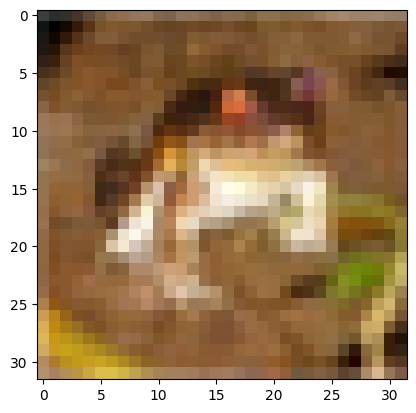

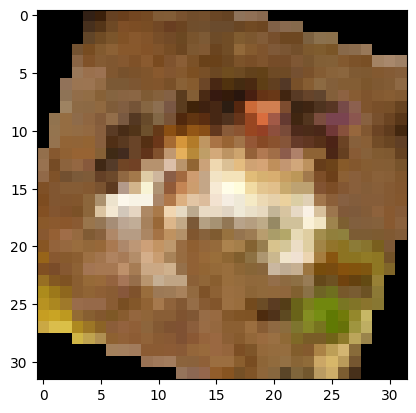

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from matplotlib import pyplot as plt


transform = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.ToTensor()
])

train_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, download=True)
img, label = train_ds[0]

plt.imshow(img.permute(1,2,0))
plt.show()

img, label = train_ds[0]

plt.imshow(img.permute(1,2,0))
plt.show()

Widzimy tutaj kolejny potencjalny problem z augmentacjami: ze względu na konieczność utrzymania stałego kształtu wejścia, augmentacje mogą wprowadzać artefakty takie jak czarne fragmenty na krawędziach obrazu czy aliasing wynikający z niskiej rozdzielczości.

Poniżej kod pomocniczy z laboratorium 3, można zastąpić go własną implementacją pętli uczącej uwzględniającej ulepszenia wykonane na laboratoriach 4 i 5. W zadaniach poniżej wystarczy porównać końcowy wynik uczenia, nie jest wymagane wyrysowywanie pełnych krzywych w tensorboard niemniej mogą one pomóc w analizie otrzymanych wyników.

In [2]:
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from typing import Tuple
from tqdm import tqdm

transform = torchvision.transforms.ToTensor()

train_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, download=True)
test_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, train=False, download=True)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size=32, pin_memory=True)

def count_correct(
    y_pred: torch.Tensor, y_true: torch.Tensor
) -> torch.Tensor:
    preds = torch.argmax(y_pred, dim=1)
    return (preds == y_true).float().sum()

def validate(
    model: nn.Module,
    loss_fn: torch.nn.CrossEntropyLoss,
    dataloader: DataLoader
) -> Tuple[torch.Tensor, torch.Tensor]:
    loss = 0
    correct = 0
    all = 0
    for X_batch, y_batch in dataloader:
        y_pred = model(X_batch.cuda())
        all += len(y_pred)
        loss += loss_fn(y_pred, y_batch.cuda()).sum()
        correct += count_correct(y_pred, y_batch.cuda())
    return loss / all, correct / all

def fit(
    model: nn.Module, optimiser: optim.Optimizer,
    loss_fn: torch.nn.CrossEntropyLoss, train_dl: DataLoader,
    val_dl: DataLoader, epochs: int,
    print_metrics: str = True
):
  history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
  for epoch in range(epochs):
      for X_batch, y_batch in tqdm(train_dl):
          y_pred = model(X_batch.cuda())
          loss = loss_fn(y_pred, y_batch.cuda())

          loss.backward()
          optimiser.step()
          optimiser.zero_grad()

      if print_metrics:
          model.eval()
          with torch.no_grad():
              train_loss, train_acc = validate(
                  model=model, loss_fn=loss_fn, dataloader=train_dl
              )
              val_loss, val_acc = validate(
                  model=model, loss_fn=loss_fn, dataloader=val_dl
              )
              history['train_loss'].append(train_loss)
              history['train_acc'].append(train_acc)
              history['val_loss'].append(val_loss)
              history['val_acc'].append(val_acc)
  return history

# Zadanie 1

Wykorzystując klasę ThreeLayerCNN z `channels=32`, spróbuj dobrać augmentacje danych tak aby poprawić wyniki względem jej braku na zbiorze CIFAR10.

In [3]:
class ThreeLayerCNN(torch.nn.Module):
  def __init__(self, channels: int, labels: int):
    super().__init__()
    self.model = torch.nn.Sequential()
    self.model.add_module("in_conv", torch.nn.Conv2d(3, channels, 1))
    self.model.add_module("relu_1", torch.nn.ReLU())
    self.model.add_module("conv_1", torch.nn.Conv2d(channels, channels, 3, padding=1))
    self.model.add_module("relu_2", torch.nn.ReLU())
    self.model.add_module("max_pool_1", torch.nn.MaxPool2d(2))
    self.model.add_module("conv_2", torch.nn.Conv2d(channels, channels, 3, padding=1))
    self.model.add_module("relu_3", torch.nn.ReLU())
    self.model.add_module("max_pool_2", torch.nn.MaxPool2d(2))
    self.model.add_module("flatten", torch.nn.Flatten())
    self.model.add_module("linear", torch.nn.Linear(channels*8*8, labels)) #uzupełnij

  def forward(self, x):
    return self.model(x)

Zaprogramuj eksperyment tak, aby w pętli sprawdzać kolejne potencjalne wersje potoku przetwarzania (różniące się tutaj tylko augmentacją), a na końcu wybrać najlepszą - tak aby możliwe było powtórzenie całego eksperymentu uzasadniającego wybór! Transformacja z augmentacją ma być wywoływana tylko na danych treningowych.

Spróbuj znaleźć również przykład augmentacji pogarszającej wynik w stosunku do bazowego otrzymanego bez augmentacji. Wykorzystaj uczenie na 50 epok i optymalizator Adam z domyślnymi parametrami, bez regularyzacji.

In [4]:
 # zaprojektuj eksperyment sprawdzający kilka możliwych podejść do augmentacji, wybranych z dokumentacji torchvision.transforms

test_transform = transforms.Compose([transforms.ToTensor()])

transforms_dict = {
    "Baseline": transforms.Compose([transforms.ToTensor()]),
    "Rotation": transforms.Compose([transforms.RandomRotation(30), transforms.ToTensor()]),
    "Geometric (V-Flip)": transforms.Compose([
        transforms.RandomVerticalFlip(p=1.0),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor()
    ]),
    "Color": transforms.Compose([transforms.ColorJitter(0.2, 0.2, 0.2), transforms.ToTensor()]),
    "Erase": transforms.Compose([transforms.ToTensor(), transforms.RandomErasing(p=0.5)])
}

all_histories = {}
EPOCHS = 50

for name, transform in transforms_dict.items():
  print(f"\n Augmentation - {name}")

  train_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, download=True)
  test_ds = torchvision.datasets.CIFAR10("cifar_root", transform=test_transform, train=False, download=True)

  train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, pin_memory=True)
  test_dl = DataLoader(test_ds, batch_size=32, pin_memory=True)

  cnn_model = ThreeLayerCNN(32, 10).cuda()
  optimizer = optim.Adam(cnn_model.parameters())
  loss_fn = nn.CrossEntropyLoss()

  history = fit(cnn_model, optimizer, loss_fn, train_dl, test_dl, EPOCHS, True)
  all_histories[name] = history



 Augmentation - Baseline


100%|██████████| 1563/1563 [00:11<00:00, 139.36it/s]



 Augmentation - Rotation


100%|██████████| 1563/1563 [00:15<00:00, 99.04it/s] 



 Augmentation - Geometric (V-Flip)


100%|██████████| 1563/1563 [00:18<00:00, 83.27it/s]



 Augmentation - Color


100%|██████████| 1563/1563 [00:27<00:00, 56.80it/s]



 Augmentation - Erase


100%|██████████| 1563/1563 [00:18<00:00, 82.75it/s]


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

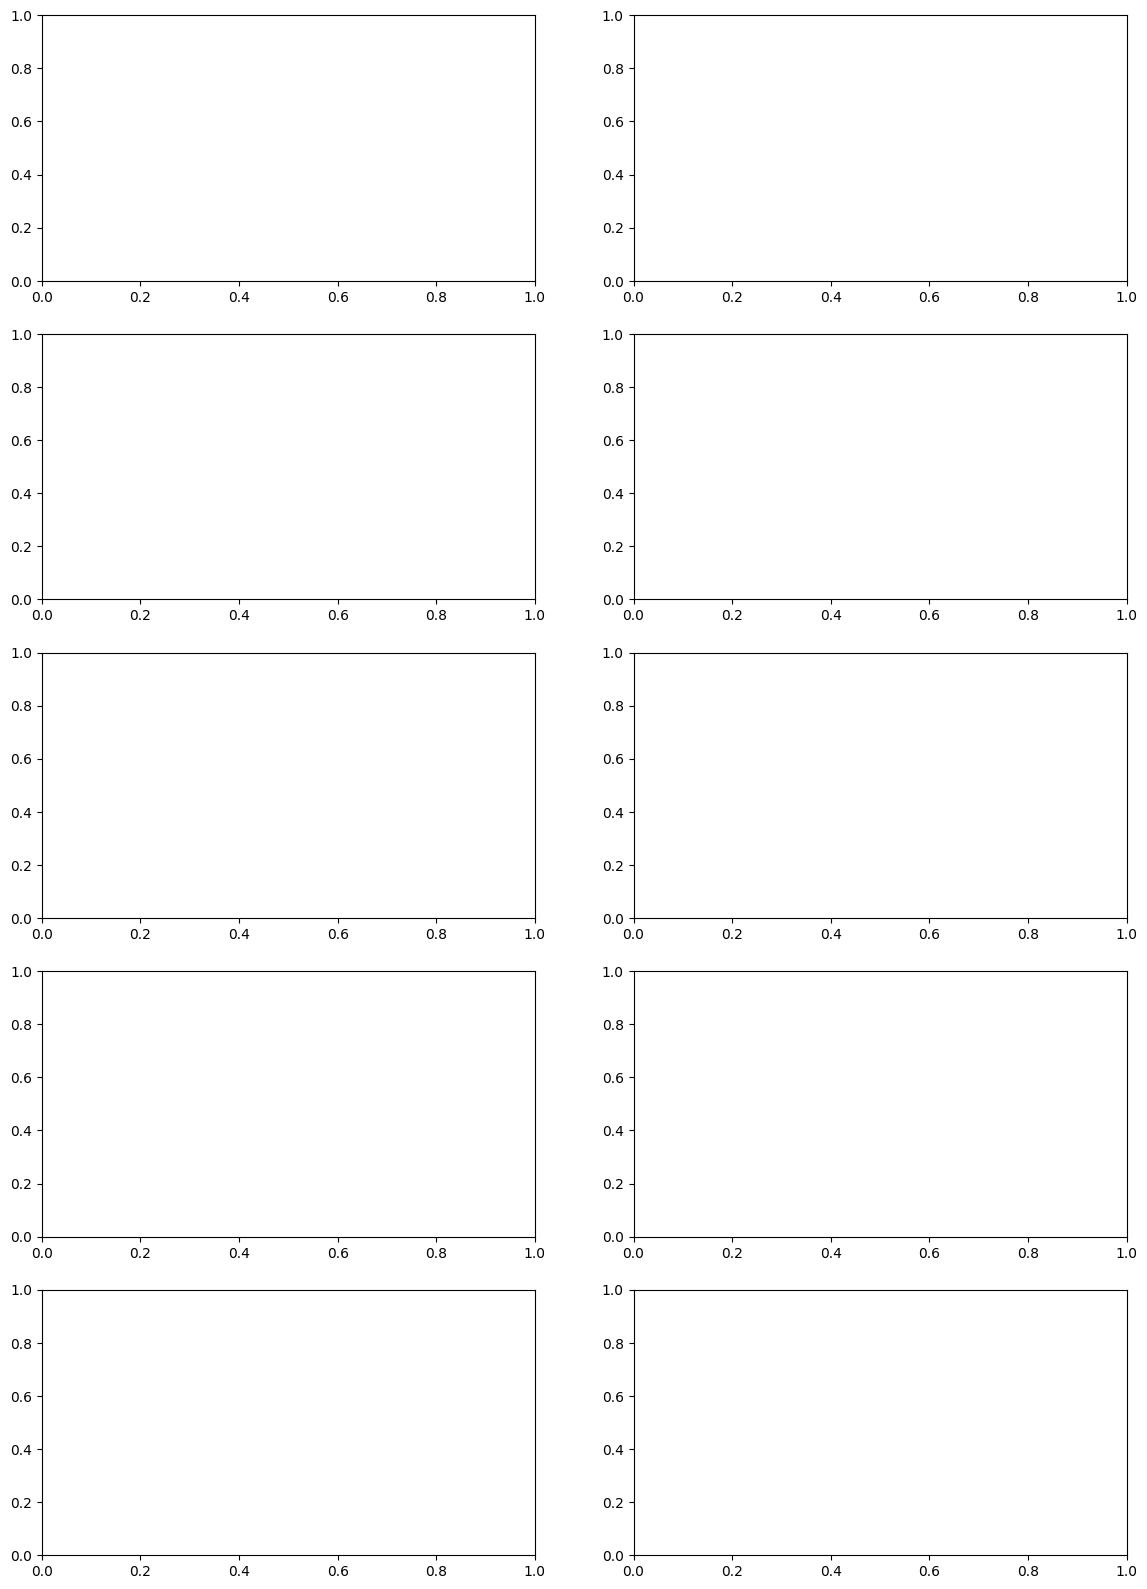

In [5]:
num_experiments = len(all_histories)
fig, axes = plt.subplots(num_experiments, 2, figsize=(14, 4 * num_experiments))

for i, (name, hist) in enumerate(all_histories.items()):
    train_loss = [float(x) for x in hist['train_loss']]
    val_loss = [float(x) for x in hist['val_loss']]
    train_acc = [float(x) for x in hist['train_acc']]
    val_acc = [float(x) for x in hist['val_acc']]

    axes[i, 0].plot(hist['train_loss'], label='Train Loss', color='crimson', linewidth=2)
    axes[i, 0].plot(hist['val_loss'], label='Val Loss', color='darkorange', linewidth=2, linestyle='--')
    axes[i, 0].set_title(f"[{name}] Cross Entropy Loss")
    axes[i, 0].set_xlabel("Epoch")
    axes[i, 0].set_ylabel("Loss")
    axes[i, 0].legend()
    axes[i, 0].grid(True, linestyle=':', alpha=0.6)

    axes[i, 1].plot(hist['train_acc'], label='Train Acc', color='forestgreen', linewidth=2)
    axes[i, 1].plot(hist['val_acc'], label='Val Acc', color='royalblue', linewidth=2, linestyle='--')
    axes[i, 1].set_title(f"[{name}] Accuracy")
    axes[i, 1].set_xlabel("Epoch")
    axes[i, 1].set_ylabel("Accuracy")
    axes[i, 1].legend()
    axes[i, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Mixup - augmentacja ogólna

Augmentacja daje nam spore możliwości w sytuacji, gdy w dziedzinie danych jesteśmy w stanie wskazać przekształcenia na kóre nasz model powinien być **inwariantny** - dla obrazków niewielkie skalowanie czy przesunięcie nie powinno zmieniać wyniku, zaś dla tekstu, podstawianie synonimów może spełniać podobną rolę. Ale w augmentacji danych możliwe jest też podejście niezależne od typu danych, wynikające z obserwacji dotyczących dynamiki uczenia sieci głębokich w ogóle. Ciekawym przykładem jest tu augmentacja Mixup:

https://arxiv.org/abs/1710.09412

Zasada działania mixup jest niezwykle prosta - generujemy nowe przykłady jako **kombinacje liniowe** tych istniejących w zbiorze danych i oczekujemy, że ich etykiety również będą kombinacjami liniowymi etykiet. Innymi słowy, dla pary przykładów z etykietami: $(x_1, y_1)$, $(x_2, y_2)$, możemy wygenerować przykład $(x', y')$:

$x' = \lambda x_1 + (1-\lambda) x_2$

$y' = \lambda y_1 + (1-\lambda) y_2$

Wartość $\lambda$ jest tutaj losowana z rozkładu Beta - animacja podana na https://en.wikipedia.org/wiki/Beta_distribution#Definitions dobrze obrazuje, jak wygląda ten rozkład dla różnych parametryzacji.

# Zadanie 2

Zmodyfikuj funkcję fit tak, aby uczyć zgodnie z podanym wyżej sformułowaniem augmentacji Mixup. (Pamiętaj, że model musi przyjmować etykiety w postaci kombinacji dwóch klas. Będzie to wymagało modyfikacji funkcji kosztu! )

In [ ]:
def fit(
    model: nn.Module, optimiser: optim.Optimizer,
    loss_fn: torch.nn.CrossEntropyLoss, train_dl: DataLoader,
    val_dl: DataLoader, epochs: int,
    print_metrics: str = True
):
  history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
  alpha = 0.2

  for epoch in range(epochs):
      model.train()
      for X_batch, y_batch in tqdm(train_dl):
          X_batch, y_batch = X_batch.cuda(), y_batch.cuda()

          if alpha > 0:
            lam = np.random.beta(alpha, alpha)
          else:
            lam = 1.0

          batch_size = X_batch.size()[0]
          index = torch.randperm(batch_size).cuda()

          mixed_X = lam * X_batch + (1 - lam) * X_batch[index]
          y_a, y_b = y_batch, y_batch[index]
          y_pred = model(mixed_X)
          loss = lam * loss_fn(y_pred, y_a) + (1 - lam) * loss_fn(y_pred, y_b)

          loss.backward()
          optimiser.step()
          optimiser.zero_grad()

      if print_metrics:
          model.eval()
          with torch.no_grad():
              train_loss, train_acc = validate(
                  model=model, loss_fn=loss_fn, dataloader=train_dl
              )
              val_loss, val_acc = validate(
                  model=model, loss_fn=loss_fn, dataloader=val_dl
              )
              history['train_loss'].append(train_loss)
              history['train_acc'].append(train_acc)
              history['val_loss'].append(val_loss)
              history['val_acc'].append(val_acc)
  return history

Sprawdź, czy uzyskuje ona przewagę nad modelem trenowanym bez augmentacji.



In [ ]:
# przetestuj wyniki z wykorzystaniem zmodyfikowanego fit()

transform = torchvision.transforms.ToTensor()

train_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, download=True)
test_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, train=False, download=True)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size=32, pin_memory=True)

cnn_model = ThreeLayerCNN(32, 10).cuda()
optimizer = optim.Adam(cnn_model.parameters())
loss_fn = nn.CrossEntropyLoss()

name = "Mixup"
history = fit(cnn_model, optimizer, loss_fn, train_dl, test_dl, EPOCHS, True)
all_histories[name] = history
sub_histories = [all_histories["Baseline"], all_histories["Mixup"]]

for i, (name, hist) in enumerate(sub_histories.items()):
    axes[i, 0].plot(hist['train_loss'], label='Train Loss', color='crimson', linewidth=2)
    axes[i, 0].plot(hist['val_loss'], label='Val Loss', color='darkorange', linewidth=2, linestyle='--')
    axes[i, 0].set_title(f"[{name}] Cross Entropy Loss")
    axes[i, 0].set_xlabel("Epoch")
    axes[i, 0].set_ylabel("Loss")
    axes[i, 0].legend()
    axes[i, 0].grid(True, linestyle=':', alpha=0.6)

    axes[i, 1].plot(hist['train_acc'], label='Train Acc', color='forestgreen', linewidth=2)
    axes[i, 1].plot(hist['val_acc'], label='Val Acc', color='royalblue', linewidth=2, linestyle='--')
    axes[i, 1].set_title(f"[{name}] Accuracy")
    axes[i, 1].set_xlabel("Epoch")
    axes[i, 1].set_ylabel("Accuracy")
    axes[i, 1].legend()
    axes[i, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Skrótowe połączenia

W kontekście sieci konwolucyjnych warto zpoznać się jeszcze z jedną istotną koncepcją: połączenia omijające warstwy, poprzez konkatenacje ich wyniku z wynikami dalszych warstw lub dodawanie ich wyniku do wyjścia dalszej warstwy (w drugim przypadku mówimy też o połączeniach *rezydualnych*). Połączenia takie są potrzebne szczególnie przy trenowaniu sieci bardzo głębokich, zawierających dziesiątki czy nawet ponad 100 warstw, czego nie będziemy w stanie realistycznie zrealizować w czasie naszych laboratoriów. Niemniej warto zapoznać się zarówno z samą ideą, jak i ich implementacją, jako że przy pracy z architekturami *state of the art* będziemy często natykać się na takie konstrukcje.

W konstrukcji sieci z połączeniamy pomijającymi warstwy i połączeniami rezydualnymi często będziemy spotykać się z powtarzalnymi *blokami* obejmującymi kilka warstw - dobrą praktyką implementacyjną jest wydzielanie takich bloków jako osobnych podklas `torch.nn.Module`. Warto też z góry zwrócić uwagę, że znane nam już `torch.nn.Sequential` nie uwzględnia połączeń innych niż sekwencyjne - czyli połączenia rezydualne i omijanie warstw nie wchodzi w grę, chyba że w obrębie wydzielonego bloku.

# Zadanie 3

Uzupełnij kod klasy SkipBlock tak, aby implementowała blok o zadanej strukturze.

Struktura SkipBlock:


*  zadana liczba `n` warstw konwolucyjnch, `channels x channels` kanałów, filtr 3x3, padding 1
*  aktywacja ReLU po każdej warstwie
*  pooling 2x pod koniec całego bloku
*  parametr `skip`: jeśli jest ustawiony na `true`, do wyjścia po ReLU należy **dodać** pierwotne wejście do warstwy konwolucyjnej, jeśli `false` mamy zwyczajną sekwencję warstw konwolucyjnych z aktywacjami

(Dla `skip=false` i `n=1` struktura sieci powinna odpowiadać ThreeLayerCNN powyżej.)

In [ ]:
from torch.futures import wait_all
class SkipBlock(torch.nn.Module)
  def __init__(self, skip: bool, n: int, channels: int):
    self.skip = skip
    self.n = n
    self.convs = nn.ModuleList([
        nn.Conv2d(channels, channels, kernel_size=3, padding=1) for _ in range(n)
    ])
    self.relus = nn.ModuleList([
        nn.ReLU() for _ in range(n)
    ])
    self.max_pool = nn.MaxPool2d(2)

  def forward(self, x):
    for i in range(self.n):
      identity = x
      x = self.convs[i](x)
      x = self.relus[i](x)

      if self.skip:
        x = x + identity

    x = self.max_pool(x)
    return x


class SkipBlockCNN(torch.nn.Module):
  def __init__(self, channels: int, labels: int, n:int,  skip: bool):
    super().__init__()
    self.model = torch.nn.Sequential()
    self.model.add_module("in_conv", nn.Conv2d(3, channels, 1))
    self.model.add_module("in_relu", nn.ReLU())
    self.model.add_module("skip_1", SkipBlock(skip, n, channels))
    self.model.add_module("skip_2", SkipBlock(skip, n, channels))
    self.model.add_module("flatten", torch.nn.Flatten())
    self.model.add_module("linear", channels*8*8, labels) #uzupełnij

  def forward(self, x):
    return self.model(x)

 Wyucz sieć SkipBlockCNN i porównaj jej wyniki z wcześniej uzykanymi. Porównaj wyniki w zależności od tego, czy włączone są skip connections.

In [ ]:
# wyucz sieć i porównaj wyniki

options = {
    "NoSkip": SkipBlockCNN(channels=32, labels=10, n=3, skip=True),
    "Skip": SkipBlockCNN(channels=32, labels=10, n=3, skip=False),
}

for name, model in options.items():
  optimizer = optim.Adam(model.parameters())

  history = fit(model, optimizer, loss_fn, train_dl, test_dl, EPOCHS, True)
  sub_histories[name] = history

for i, (name, hist) in enumerate(sub_histories.items()):
    axes[i, 0].plot(hist['train_loss'], label='Train Loss', color='crimson', linewidth=2)
    axes[i, 0].plot(hist['val_loss'], label='Val Loss', color='darkorange', linewidth=2, linestyle='--')
    axes[i, 0].set_title(f"[{name}] Cross Entropy Loss")
    axes[i, 0].set_xlabel("Epoch")
    axes[i, 0].set_ylabel("Loss")
    axes[i, 0].legend()
    axes[i, 0].grid(True, linestyle=':', alpha=0.6)

    axes[i, 1].plot(hist['train_acc'], label='Train Acc', color='forestgreen', linewidth=2)
    axes[i, 1].plot(hist['val_acc'], label='Val Acc', color='royalblue', linewidth=2, linestyle='--')
    axes[i, 1].set_title(f"[{name}] Accuracy")
    axes[i, 1].set_xlabel("Epoch")
    axes[i, 1].set_ylabel("Accuracy")
    axes[i, 1].legend()
    axes[i, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

